In [ ]:
import os, glob, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cfgrib
import xarray as xr
import cartopy
plt.colorbar(im, ax=axes.tolist(), label="Precipitation (mm)")
import cartopy.crs as ccrs
import cartopy.feature as cfeature

C:\Users\maili\AppData\Local\Temp\ipykernel_27336\3526756172.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes.tolist(), label="Precipitation (mm)")


<Figure size 640x480 with 0 Axes>

In [51]:
path          = 'C:\\Users\\maili\\Desktop\\KU\\AppMachineLearning\\Final_Project\\data\\'
MODEL_PATH    = 'saved_models/best_precip_model_2015_2026_deacc_6_hour_horizon_2.pt'
LAG           = 12
HORIZON       = 6 #12 used for long run
FINAL_EPOCHS  = 40
BATCH         =  64 # 128
SEED          = 42
RAIN_THRESH   = 0.1   # mm — threshold for "raining"
TARGET_HOUR   = 16    # predict precipitation at 16:00 next day
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [52]:
ds0 = xr.open_dataset("data/ds0_all_years_deacc_2.nc")
ds1 = xr.open_dataset("data/ds1_all_years_deacc_2.nc")

tp_np   = ds1["tp"].values.astype(np.float32)    # numpy from the start
ssrd_np = ds1["ssrd"].values.astype(np.float32)

In [53]:

N_valid    = len(ds0.time) - HORIZON
ds0_time   = ds0.time.values

# target: tp at T+24h in mm
y_raw_mm = tp_np[HORIZON:] * 1000

# input channels
channels, chan_names = [], []
for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
    channels.append(ds0[var].values[:N_valid].astype(np.float32))
    chan_names.append(var)
channels.append(tp_np[:N_valid].astype(np.float32) * 1000)
chan_names.append("tp")
channels.append(ssrd_np[:N_valid].astype(np.float32))
chan_names.append("ssrd")

ref_time   = ds0_time[:N_valid]
N_FEATURES = len(channels)

print(f"N_valid: {N_valid}")
print(f"Target range: {y_raw_mm.min():.4f} – {y_raw_mm.max():.4f} mm")
print(f"Target NaNs: {np.isnan(y_raw_mm).sum()}")
for name, ch in zip(chan_names, channels):
    print(f"  {name}: {ch.shape}")

N_valid: 96618
Target range: 0.0000 – 10.6587 mm
Target NaNs: 0
  sp: (96618, 5, 5)
  tcc: (96618, 5, 5)
  u10: (96618, 5, 5)
  v10: (96618, 5, 5)
  t2m: (96618, 5, 5)
  tp: (96618, 5, 5)
  ssrd: (96618, 5, 5)


In [54]:
print("y_raw_mm percentiles:")
for p in [50, 90, 95, 99, 100]:
    print(f"  {p}%: {np.percentile(y_raw_mm[:, 2, 2], p):.4f} mm")
print("Rainy fraction (>0.1mm):", (y_raw_mm[:, 2, 2] > 0.1).mean())

y_raw_mm percentiles:
  50%: 0.0000 mm
  90%: 0.0439 mm
  95%: 0.1516 mm
  99%: 0.7227 mm
  100%: 5.2538 mm
Rainy fraction (>0.1mm): 0.0657848434039206


In [55]:
# ── log transform & stack
X_raw = np.stack(channels, axis=1).astype(np.float32)   # (96600, 7, 5, 5)
y_raw = np.log1p(y_raw_mm)                               # (96600, 5, 5)

tp_idx   = chan_names.index("tp")
ssrd_idx = chan_names.index("ssrd")
X_raw[:, tp_idx] = np.log1p(X_raw[:, tp_idx])
ssrd_mean = X_raw[:, ssrd_idx].mean()
ssrd_std  = X_raw[:, ssrd_idx].std() + 1e-8
X_raw[:, ssrd_idx] = (X_raw[:, ssrd_idx] - ssrd_mean) / ssrd_std
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X_raw: {X_raw.shape} | y_raw: {y_raw.shape}")
print(f"y_raw range: {y_raw.min():.4f} – {y_raw.max():.4f}")
print(f"X_raw NaNs: {np.isnan(X_raw).sum()} | y_raw NaNs: {np.isnan(y_raw).sum()}")


X_raw: (96618, 7, 5, 5) | y_raw: (96618, 5, 5)
y_raw range: 0.0000 – 2.4561
X_raw NaNs: 0 | y_raw NaNs: 0


In [56]:
def make_windows(X, y, lag=LAG):
    idx = np.arange(lag, len(X))
    Xw  = np.stack([X[i-lag:i] for i in idx]).astype(np.float32)
    yw  = y[idx].astype(np.float32)
    return Xw, yw

X_all_w, y_all = make_windows(X_raw, y_raw)
print(f"Windows: X={X_all_w.shape}, y={y_all.shape}")

# ── split
train_end = int(0.70 * len(X_all_w))
val_end   = int(0.85 * len(X_all_w))
X_train_w, y_train = X_all_w[:train_end],        y_all[:train_end]
X_val_w,   y_val   = X_all_w[train_end:val_end], y_all[train_end:val_end]
X_test_w,  y_test  = X_all_w[val_end:],          y_all[val_end:]


Windows: X=(96606, 12, 7, 5, 5), y=(96606, 5, 5)


In [57]:
def fit_scale(Xw):
    # Xw shape: (N, lag, C, H, W)
    # compute mean/std per channel, over N, lag, H, W
    mean = Xw.mean(axis=(0, 1, 3, 4))  # shape: (C,)
    std  = Xw.std(axis=(0, 1, 3, 4)) + 1e-8  # shape: (C,)
    return mean, std

def transform(Xw, sc):
    m, s = sc
    # broadcast (C,) over (N, lag, C, H, W)
    return ((Xw - m[None, None, :, None, None]) / 
             s[None, None, :, None, None]).astype(np.float32)

In [58]:
# ── scale inputs
scaler  = fit_scale(X_train_w)
X_tr_sc = transform(X_train_w, scaler)
X_va_sc = transform(X_val_w,   scaler)
X_te_sc = transform(X_test_w,  scaler)
y_tr, y_va, y_te = y_train, y_val, y_test

# ── oversample rainy windows  
#rain_thresh_mm = 0.01
y_tr_mm = np.expm1(y_tr)

rainy_windows = (y_tr_mm > RAIN_THRESH).any(axis=(1, 2))
rainy_idx     = np.where(rainy_windows)[0]
dry_idx       = np.where(~rainy_windows)[0]

print(f"Rainy windows: {len(rainy_idx)} ({100*len(rainy_idx)/len(y_tr):.1f}%)")
print(f"Dry windows:   {len(dry_idx)}")

OVERSAMPLE    = 1 # double the amount of rainy windows
rainy_idx_rep = np.tile(rainy_idx, OVERSAMPLE)
all_idx       = np.concatenate([dry_idx, rainy_idx_rep])
np.random.shuffle(all_idx)

X_tr_bal = X_tr_sc[all_idx]
y_tr_bal  = y_tr[all_idx]

print(f"Balanced training set: {len(X_tr_bal)} windows")
print(f"Rainy fraction after balancing: {(np.expm1(y_tr_bal) > RAIN_THRESH).any(axis=(1,2)).mean():.3f}")



Rainy windows: 15570 (23.0%)
Dry windows:   52054
Balanced training set: 67624 windows
Rainy fraction after balancing: 0.230


In [59]:

# ── 8. DATASET & LOADER ───────────────────────────────────────────────────────
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def loader(X, y, shuffle):
    return DataLoader(SeqDS(X, y), batch_size=BATCH, shuffle=shuffle,
                      num_workers=0, pin_memory=False)


In [60]:
# ── 9. MODEL ──────────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden):
        super().__init__()
        self.conv = nn.Conv2d(in_ch + hidden, 4 * hidden, 3, padding=1)
        self.hidden = hidden
    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, g, o = gates.chunk(4, dim=1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)
        return h, c
    
class ConvLSTMModel(nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.2):
        super().__init__()
        self.hidden = hidden
        self.cell   = ConvLSTMCell(in_ch, hidden)
        self.norm   = nn.GroupNorm(8, hidden)
        self.drop   = nn.Dropout2d(dropout)
        self.backbone = nn.Sequential(
            nn.Conv2d(hidden,        hidden,      3, padding=1), nn.ReLU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(hidden,        hidden // 2, 3, padding=1), nn.ReLU(),
        )
        self.prob_head   = nn.Conv2d(hidden // 2, 1, 1)
        self.amount_head = nn.Conv2d(hidden // 2, 1, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden, H, W, device=x.device)
        c = torch.zeros(B, self.hidden, H, W, device=x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        h    = self.drop(self.norm(h))
        feat = self.backbone(h)
        prob   = self.prob_head(feat).squeeze(1)    # raw logits, NO sigmoid
        amount = self.amount_head(feat).squeeze(1)
        return prob, amount

In [61]:
RAIN_THRESH_LOG = np.log1p(RAIN_THRESH)

# tune these:
RAIN_WEIGHT     = 10.0   # was 20.0 — lower = less aggressive rain upweighting
BCE_POS_WEIGHT  = 2.0    # weight on positive (rainy) class in BCE — lower = penalise false alarms more

def rain_loss(prob_logits, amount, target):
    rain_mask = (target > RAIN_THRESH_LOG).float()

    # pos_weight < 1 penalises false alarms more than misses
    pos_w = torch.tensor(BCE_POS_WEIGHT, device=prob_logits.device)
    bce   = nn.functional.binary_cross_entropy_with_logits(
                prob_logits, rain_mask, pos_weight=pos_w)

    weight   = 1.0 + RAIN_WEIGHT * rain_mask
    mse      = (weight * (amount - target) ** 2).mean()
    mae      = (weight * torch.abs(amount - target)).mean()
    amt_loss = 0.7 * mse + 0.3 * mae

    return bce + amt_loss, bce, amt_loss

In [62]:
best_hidden  = 32
best_lr      = 1e-4
best_dropout = 0.3

model     = ConvLSTMModel(N_FEATURES, best_hidden, best_dropout).to(device)
opt       = torch.optim.Adam(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                        factor=0.5, patience=2)

tr_loader = loader(X_tr_bal, y_tr_bal, True)
va_loader = loader(X_va_sc,  y_va,     False)


best_val, best_state = float("inf"), None
train_losses, val_losses = [], []
PATIENCE, patience_counter = 5, 0

for epoch in range(FINAL_EPOCHS):
    model.train()
    tl = []
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        prob, amount = model(xb)
        loss, bce, amt_loss = rain_loss(prob, amount, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl.append(loss.item())
    train_losses.append(np.mean(tl))

    model.eval()
    vl = []
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            l, _, _ = rain_loss(*model(xb), yb)
            vl.append(l.item())
    val = np.mean(vl)
    val_losses.append(val)
    scheduler.step(val)

    print(f"Epoch {epoch+1:02d}: train={train_losses[-1]:.5f}, val={val:.5f}")

    if val < best_val:
        best_val   = val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val:.5f}")

Epoch 01: train=0.52009, val=0.49139
Epoch 02: train=0.46918, val=0.47736
Epoch 03: train=0.45943, val=0.47100
Epoch 04: train=0.45231, val=0.47025
Epoch 05: train=0.44860, val=0.47069
  No improvement (1/5)
Epoch 06: train=0.44594, val=0.46522
Epoch 07: train=0.44402, val=0.46393
Epoch 08: train=0.44258, val=0.46292
Epoch 09: train=0.44005, val=0.46504
  No improvement (1/5)
Epoch 10: train=0.43807, val=0.46336
  No improvement (2/5)
Epoch 11: train=0.43702, val=0.46503
  No improvement (3/5)
Epoch 12: train=0.43435, val=0.46206
Epoch 13: train=0.43362, val=0.46276
  No improvement (1/5)


KeyboardInterrupt: 

In [63]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "hidden_size": best_hidden,
    "dropout": best_dropout,
    "n_features": N_FEATURES,
    "scaler": scaler,
    "ssrd_mean": ssrd_mean,
    "ssrd_std": ssrd_std,
}

torch.save(
    checkpoint,
    "saved_models/best_precip_model_2015_2026.pth"
)

In [64]:
# check if its actually learning
model.eval()
with torch.no_grad():
    xb, yb = next(iter(va_loader))
    xb, yb = xb.to(device), yb.to(device)
    prob_logits, amount = model(xb)
    prob = torch.sigmoid(prob_logits)
    amount_mm = torch.expm1(amount)
    target_mm = torch.expm1(yb)

print("Predicted prob range:", prob.min().item(), "–", prob.max().item())
print("Predicted amount (mm):", amount_mm.min().item(), "–", amount_mm.max().item())
print("Target amount (mm):", target_mm.min().item(), "–", target_mm.max().item())
print("Fraction rainy predicted:", (prob > 0.5).float().mean().item())
print("Fraction rainy in target:", (yb > RAIN_THRESH_LOG).float().mean().item())

Predicted prob range: 0.0032020495273172855 – 0.1925649493932724
Predicted amount (mm): -0.008577549830079079 – 0.12950672209262848
Target amount (mm): 0.0 – 0.12969970703125
Fraction rainy predicted: 0.0
Fraction rainy in target: 0.0012499999720603228


In [65]:
model.load_state_dict(best_state)
print(f"\nLoaded best model — val loss: {best_val:.5f}")


Loaded best model — val loss: 0.46206


           TEST SET METRICS
  MAE          : 0.0765 mm
  RMSE         : 0.1574 mm
  Bias         : 0.0413 mm
  Correlation  : 0.2293
---------------------------------------------
  POD (recall) : 0.9545  (fraction of rain events caught)
  FAR          : 0.7956  (fraction of rain alarms that are false)
  CSI          : 0.2024  (overall skill, 1=perfect)


C:\Users\maili\AppData\Local\Temp\ipykernel_27336\2350646072.py:97: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\maili\AppData\Local\Temp\ipykernel_27336\2350646072.py:98: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('plots/evaluation.png', dpi=150)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


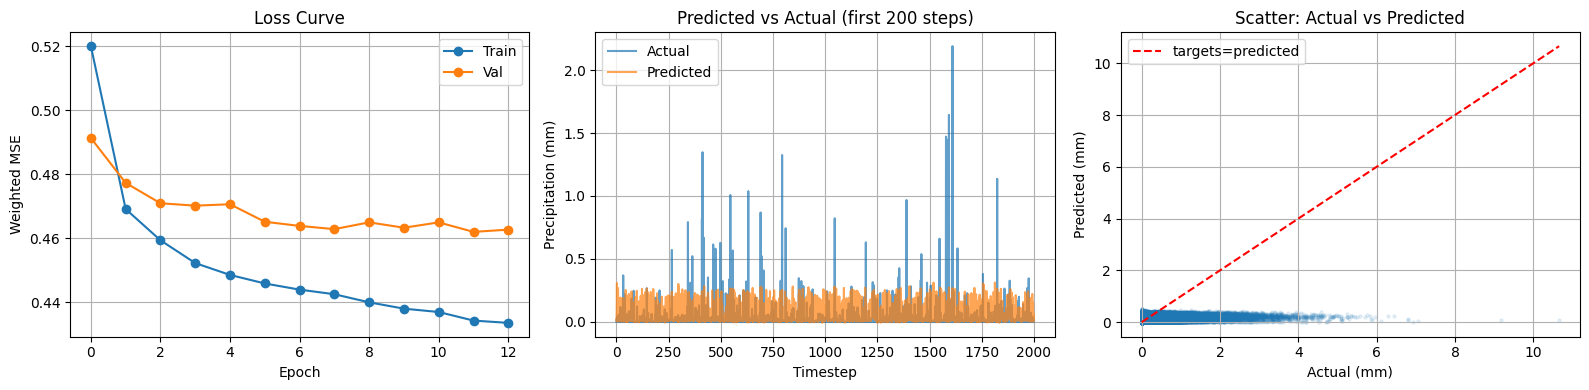

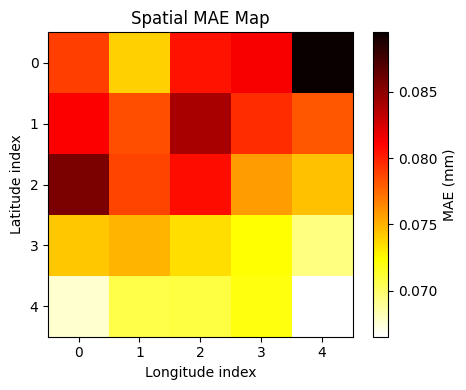

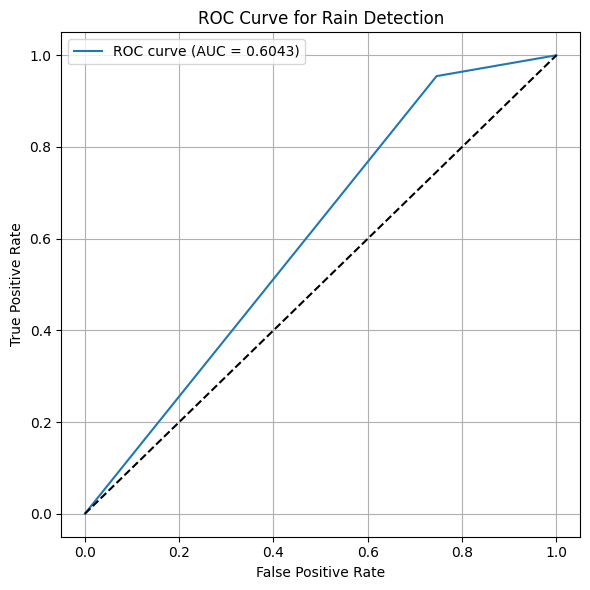

In [89]:
# ── collect predictions on test set
model.eval()
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
all_probs, all_amounts, all_targets = [], [], []

with torch.no_grad():
    for xb, yb in tr_loader:
        xb = xb.to(device)
        prob_logits, amount = model(xb)
        prob = torch.sigmoid(prob_logits).cpu().numpy()   # (B, H, W) 0-1
        all_probs.append(prob)
        all_amounts.append(amount.cpu().numpy())
        all_targets.append(yb.numpy())

probs   = np.concatenate(all_probs,   axis=0)  # (N, H, W)
amounts = np.concatenate(all_amounts, axis=0)  # (N, H, W)
targets = np.concatenate(all_targets, axis=0)  # (N, H, W)

# ── inverse transform
amounts_mm = np.expm1(amounts)   # back to mm
targets_mm = np.expm1(targets)

# ── for scatter/metrics use amount head
preds_mm   = amounts_mm
preds_flat   = preds_mm.reshape(-1)
targets_flat = targets_mm.reshape(-1)

# ── 1. SCALAR METRICS ─────────────────────────────────────────────────────────
mae  = mean_absolute_error(targets_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(targets_flat, preds_flat))
bias = (preds_flat - targets_flat).mean()

# correlation
corr = np.corrcoef(targets_flat, preds_flat)[0, 1]

# skill scores for rain detection (binary)
threshold = 0.01  # 0.1 mm threshold for "rain event"
pred_rain   = preds_flat   > threshold
target_rain = targets_flat > threshold

hits        = (pred_rain  & target_rain).sum()
misses      = (~pred_rain & target_rain).sum()
false_alarm = (pred_rain  & ~target_rain).sum()
correct_neg = (~pred_rain & ~target_rain).sum()

pod  = hits / (hits + misses + 1e-8)          # probability of detection
far  = false_alarm / (hits + false_alarm + 1e-8)  # false alarm ratio
csi  = hits / (hits + misses + false_alarm + 1e-8)  # critical success index

print("=" * 45)
print("           TEST SET METRICS")
print("=" * 45)
print(f"  MAE          : {mae:.4f} mm")
print(f"  RMSE         : {rmse:.4f} mm")
print(f"  Bias         : {bias:.4f} mm")
print(f"  Correlation  : {corr:.4f}")
print("-" * 45)
print(f"  POD (recall) : {pod:.4f}  (fraction of rain events caught)")
print(f"  FAR          : {far:.4f}  (fraction of rain alarms that are false)")
print(f"  CSI          : {csi:.4f}  (overall skill, 1=perfect)")
print("=" * 45)

# ── 2. TRAINING CURVE ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses,   label='Val',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].legend()
axes[0].grid(True)

# ── 3. PREDICTED VS ACTUAL (spatial mean over grid) ───────────────────────────
pred_ts   = preds_mm.mean(axis=(1,2))      # mean over 5×5 grid → mm
target_ts = targets_mm.mean(axis=(1,2)) 

axes[1].plot(target_ts[:2000], label='Actual',    alpha=0.7)
axes[1].plot(pred_ts[:2000],   label='Predicted', alpha=0.7)
axes[1].set_title('Predicted vs Actual (first 200 steps)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(True)

# ── 4. SCATTER PLOT ───────────────────────────────────────────────────────────
axes[2].scatter(targets_flat , preds_flat , alpha=0.1, s=5)
axes[2].plot([0, targets_flat.max()],
             [0, targets_flat.max()], 'r--', label='targets=predicted')
axes[2].set_title('Scatter: Actual vs Predicted')
axes[2].set_xlabel('Actual (mm)')
axes[2].set_ylabel('Predicted (mm)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('plots/evaluation.png', dpi=150)
plt.show()

# ── 5. SPATIAL ERROR MAP ──────────────────────────────────────────────────────
mae_map = np.abs(preds_mm - targets_mm).mean(axis=0)   # (5, 5) in mm

fig2, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(mae_map, cmap='hot_r')
plt.colorbar(im, ax=ax, label='MAE (mm)')
ax.set_title('Spatial MAE Map')
ax.set_xlabel('Longitude index')
ax.set_ylabel('Latitude index')
plt.tight_layout()
plt.savefig('plots/spatial_mae.png', dpi=150)
plt.show()

# plot roc curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(target_rain, pred_rain)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Rain Detection')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/roc_curve.png', dpi=150)
plt.show()

In [95]:
# save after fitting scaler in training script
np.save("data/ssrd_train_mean.npy", np.array([ssrd_mean]))
np.save("data/ssrd_train_std.npy",  np.array([ssrd_std]))

# load in inference script
ssrd_mean = float(np.load("data/ssrd_train_mean.npy")[0])
ssrd_std  = float(np.load("data/ssrd_train_std.npy")[0])

In [96]:
def predict_on_new_file(ds0_new, ds1_new, model, scaler, device,
                        lag=LAG, horizon=HORIZON,
                        rain_thresh=RAIN_THRESH, target_hour=TARGET_HOUR):
    """
    ds0_new, ds1_new: xr.Dataset loaded from new NetCDF files
                      (preprocessed the same way as training data)
    """
    model.eval()

    # ── 1. Build X and y the same way as training ─────────────────────────
    tp_np   = ds1_new["tp"].values.astype(np.float32)
    ssrd_np = ds1_new["ssrd"].values.astype(np.float32)
    N_valid = len(ds0_new.time) - horizon

    y_raw_mm = tp_np[horizon:] * 1000                        # (N_valid, 5, 5)

    channels = []
    for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
        channels.append(ds0_new[var].values[:N_valid].astype(np.float32))
    channels.append(tp_np[:N_valid] * 1000)
    channels.append(ssrd_np[:N_valid])

    X_raw = np.stack(channels, axis=1).astype(np.float32)    # (N_valid, 7, 5, 5)
    y_raw = np.log1p(y_raw_mm)                               # log target

    # same transforms as training
    tp_idx, ssrd_idx = 5, 6
    X_raw[:, tp_idx]  = np.log1p(X_raw[:, tp_idx])
    X_raw[:, ssrd_idx] = (X_raw[:, ssrd_idx] - scaler[0][ssrd_idx] * 0 +
                           0) # ← use training ssrd mean/std below
    # IMPORTANT: use training scaler for ssrd, not new file stats
    ssrd_mean_tr = scaler[0][ssrd_idx] * (scaler[1][ssrd_idx])  # recover from channel scaler
    # Actually simpler — just z-score with training mean/std stored separately
    # (see note below)
    X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

    # ── 2. Windows ─────────────────────────────────────────────────────────
    X_w, y_w = make_windows(X_raw, y_raw, lag=lag)           # (N_win, lag, 7, 5, 5)
    ref_time  = ds0_new.time.values[lag:N_valid]

    # ── 3. Scale with TRAINING scaler ──────────────────────────────────────
    X_w_sc = transform(X_w, scaler)

    # ── 4. Inference in batches ────────────────────────────────────────────
    ds_inf  = SeqDS(X_w_sc, y_w)
    loader_ = DataLoader(ds_inf, batch_size=64, shuffle=False)

    preds_log, targets_log = [], []
    with torch.no_grad():
        for xb, yb in loader_:
            out = model(xb.to(device))
            # if your model returns (rain_prob, amount), take amount
            if isinstance(out, tuple):
                out = out[1]
            preds_log.append(out.cpu().numpy())
            targets_log.append(yb.numpy())

    preds_log   = np.concatenate(preds_log,   axis=0)        # (N_win, 5, 5)
    targets_log = np.concatenate(targets_log, axis=0)        # (N_win, 5, 5)

    # back to mm
    preds_mm   = np.expm1(preds_mm   := preds_log.clip(0))
    targets_mm = np.expm1(targets_log)

    # ── 5. Filter to 166:00 only ────────────────────────────────────────────
    times_dt = pd.to_datetime(ref_time)
    mask_16  = times_dt.hour == target_hour

    pred_16   = preds_mm[mask_16]                            # (N_16, 5, 5)
    target_16 = targets_mm[mask_16]
    times_16  = times_dt[mask_16]

    # ── 6. Metrics ─────────────────────────────────────────────────────────
    centre = (2, 2)
    p = pred_16[:,   centre[0], centre[1]]
    t = target_16[:, centre[0], centre[1]]

    mae  = np.abs(p - t).mean()
    rmse = np.sqrt(((p - t)**2).mean())
    bias = (p - t).mean()

    hits    = ((p > rain_thresh) & (t > rain_thresh)).sum()
    misses  = ((p <= rain_thresh) & (t > rain_thresh)).sum()
    fa      = ((p > rain_thresh) & (t <= rain_thresh)).sum()
    pod     = hits / (hits + misses + 1e-8)
    far     = fa   / (hits + fa    + 1e-8)
    csi     = hits / (hits + misses + fa + 1e-8)

    print(f"── Evaluation at {target_hour}:00 ──────────────────")
    print(f"N days evaluated : {len(times_16)}")
    print(f"MAE              : {mae:.4f} mm")
    print(f"RMSE             : {rmse:.4f} mm")
    print(f"Bias             : {bias:.4f} mm")
    print(f"POD              : {pod:.3f}")
    print(f"FAR              : {far:.3f}")
    print(f"CSI              : {csi:.3f}")

    return pred_16, target_16, times_16




In [116]:
# ── Usage ──────────────────────────────────────────────────────────────────
# load your new preprocessed file (must go through same GRIB→NetCDF pipeline9
MODEL_PATH ='saved_models/best_precip_model_2015_2026_deacc_6_hour_horizon_2.pt'
ds0_new = xr.open_dataset("data/ds0_all_years_deacc_2020.nc")   # or ds0_2020.nc
ds1_new = xr.open_dataset("data/ds1_all_years_deacc_2020.nc")

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

pred_16, target_16, times_16 = predict_on_new_file(
    ds0_new, ds1_new, model, scaler, device
)

── Evaluation at 16:00 ──────────────────
N days evaluated : 366
MAE              : 0.0735 mm
RMSE             : 0.1428 mm
Bias             : 0.0428 mm
POD              : 0.650
FAR              : 0.851
CSI              : 0.138


Available 16:00 dates: DatetimeIndex(['2020-01-01 16:00:00', '2020-01-02 16:00:00',
               '2020-01-03 16:00:00', '2020-01-04 16:00:00',
               '2020-01-05 16:00:00'],
              dtype='datetime64[ns]', freq=None)


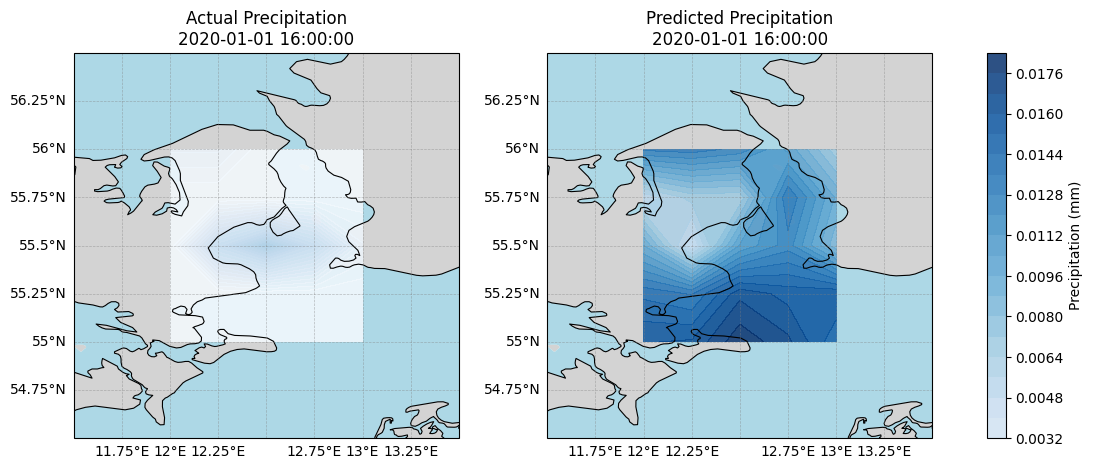

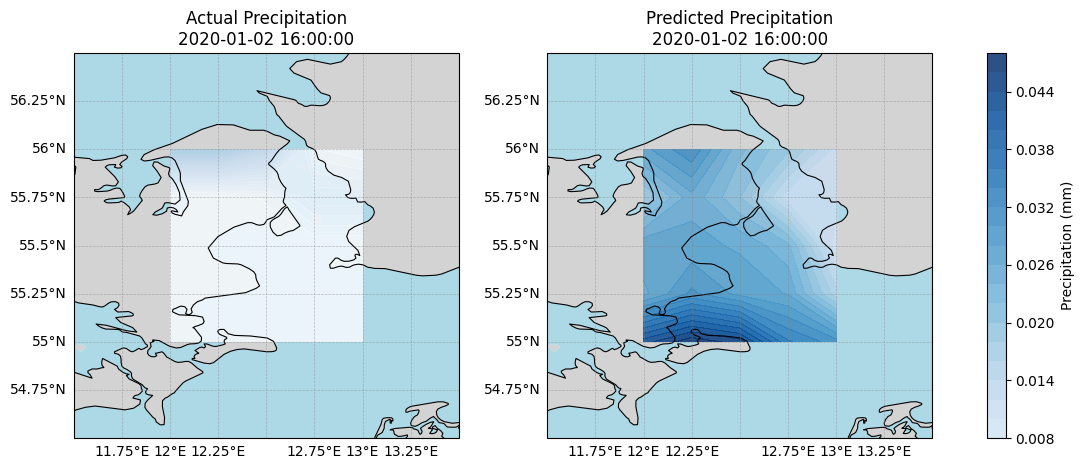

In [119]:
def plot_precip_comparison(pred_16, target_16, times_16, 
                           lats, lons, target_datetime):


    target_dt = pd.Timestamp(target_datetime)
    mask = times_16 == target_dt

    if mask.sum() == 0:
        print(f"No data found for {target_dt}")
        print("Available dates (first 5):", times_16[:5])
        return

    pred_grid   = pred_16[mask][0]    # (5, 5)
    target_grid = target_16[mask][0]  # (5, 5)

    vmax = max(pred_grid.max(), target_grid.max(), 0.01)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})

    for ax, grid, title in zip(axes, 
                                [target_grid, pred_grid], 
                                ["Actual", "Predicted"]):
        ax.add_feature(cfeature.LAND,      facecolor="lightgray")
        ax.add_feature(cfeature.OCEAN,     facecolor="lightblue")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                          color="gray", alpha=0.5, linestyle="--")
        gl.top_labels   = False
        gl.right_labels = False

        im = ax.contourf(lons, lats, grid,
                         cmap="Blues", levels=20,
                         vmin=0, vmax=vmax,
                         transform=ccrs.PlateCarree(), alpha=0.85)

        ax.set_extent([lons.min()-0.5, lons.max()+0.5,
                       lats.min()-0.5, lats.max()+0.5],
                      crs=ccrs.PlateCarree())
        ax.set_title(f"{title} Precipitation\n{target_dt}")
    plt.colorbar(im, ax=axes.tolist(), label="Precipitation (mm)")
    plt.savefig(f"plots/precip_map_{target_dt.date()}.png", dpi=150)
    plt.show()


# ── usage ──────────────────────────────────────────────────────────────────
lats = ds0_new["latitude"].values   # [56, 55.75, 55.5, 55.25, 55]
lons = ds0_new["longitude"].values  # [12, 12.25, 12.5, 12.75, 13]

# pick any date that exists in times_16
print("Available 16:00 dates:", times_16[:5])

plot_precip_comparison(pred_16, target_16, times_16,
                       lats, lons,
                       target_datetime="2020-01-01 16:00:00")
plot_precip_comparison(pred_16, target_16, times_16,
                       lats, lons,
                       target_datetime="2020-01-02 16:00:00")


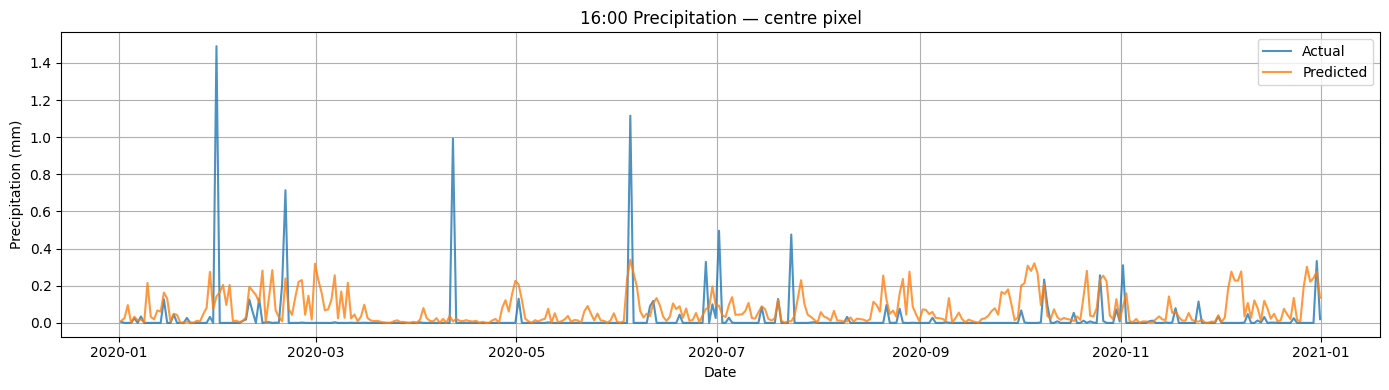

In [ ]:
def plot_timeseries_16(pred_16, target_16, times_16, pixel=(2,2)):
    p = pred_16[:,   pixel[0], pixel[1]]
    t = target_16[:, pixel[0], pixel[1]]

    plt.figure(figsize=(14, 4))
    plt.plot(times_16, t, label="Actual",    alpha=0.8)
    plt.plot(times_16, p, label="Predicted", alpha=0.8)
    plt.xlabel("Date")
    plt.ylabel("Precipitation (mm)")
    plt.title(f"16:00 Precipitation — centre pixel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("plots/timeseries_16_2020.png", dpi=150)
    plt.show()

plot_timeseries_16(pred_16, target_16, times_16)